# Субградиентный метод

В этих экспериментах мы сравним скорость сходимости субградиентного метода с убывающим шагом и с шагом Поляка.

## Phase retrieval

$$
\min_x \frac{1}{m} \sum_{i=1}^m | (a_i^\top x)^2 - b_i |
$$
, где $a_i \in \mathbb{R}^d$ и $b_i \in \mathbb{R}$.

Отметим, что задача имеет острый минимум, а так же слабо выпукла.

Данные будем генерировать следующим образом: 
- $a_i \sim N(0, I_{d \times d})$ для $i = 1, \ldots, m$ (измерения)
- $\bar{x} \sim N(0, I_{d \times d})$ (сигнал)
Затем мы устанавливаем $b_i = \langle a_i, \bar{x} \rangle^2$ для каждого $i = 1, \ldots, m$.

Далее мы будем генерировать искажения (outliers) следующим образом. Мы задаём $b_i = (1 - z_i) \langle a_i, \bar{x} \rangle^2 + z_i |\zeta_i|$, 
где $z_i \sim \text{Bernoulli}(0.1)$ и $\zeta_i \sim \mathcal{N}(0, 100)$. Делать мы это будем для того, чтобы увидеть как это повлияет на поведение алгоритмов.

Шаги для сравнения

1. Убывающий шаг: $t_k = \dfrac{1}{\|f'(\mathbf{x}^k)\|\sqrt{k+1}}$
2. Шаг Поляка: $t_k = \frac{f(x_k)-f^*}{||f'(x^k)||^2}$

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib

In [2]:
class StepSize:
    def __call__(self, x, h, k, *args, **kwargs):
        pass


class Subgrad_descent_step(StepSize):
    def __init__(self, d=1, alpha0=1, alpha_function=None):
        if alpha_function is not None:
            self.alpha_function = alpha_function
        else:
            self.alpha_function = lambda k, subgrad: alpha0/(k+1)**d
    
    def __call__(self, x, h, k, *args, **kwargs):
        return self.alpha_function(k, h)


class PolyakStepSize(StepSize):
    def __init__(self, f_sol=0, const_div=1.0):
        self.f_sol = f_sol
        self.const_div = const_div

    def __call__(self, x, h, k, gradf, f, *args, **kwargs):
        fx = f(x)
        alpha = (fx - self.f_sol) / (self.const_div * np.linalg.norm(h)**2 + 1e-12)
        return alpha

In [3]:
def phase_retrieval(A, b):
    return lambda x: np.mean(np.abs(np.dot(A, x)**2 - b))


def phase_retrieval_subgradient(A, b):
    def g(x):
        Ax = A @ x
        residuals = Ax**2 - b
        s = np.sign(residuals)
        grad_terms = (s * 2 * Ax)[:, None] * A
        return np.mean(grad_terms, axis=0)
    return g

In [ ]:
def subgrad_method(f, subgrad_f, step, x0, max_iters=1000, tol=1e-6):
    history = []
    x = x0.copy()

    for i in range(max_iters):
        subgrad = subgrad_f(x)
        if np.allclose(subgrad, 0, atol=tol):
            break
        alpha = step(x, subgrad, i, gradf=subgrad_f, f=f)
        x_new = x - alpha * subgrad
        f_current = f(x)
        if i == 0:
            history.append((f_current, x.copy()))
        elif f_current < history[-1][0]:
            history.append((f_current, x.copy()))
        else:
            history.append(history[-1])
        x = x_new

    return x, history

In [ ]:
def phase_retrieval_params(observ_nmbr, dim, rng, outliers_fraction=0.1, outliers_magnitude=100.0):
    A = np.random.randn(observ_nmbr, dim)
    x_true = np.random.randn(dim)
    
    b = np.abs(A @ x_true)**2
    indices = rng.choice(observ_nmbr, size=int(outliers_fraction * observ_nmbr), replace=False)
    b[indices] = rng.uniform(0., outliers_magnitude, size=indices.shape)

    return A, b, x_true

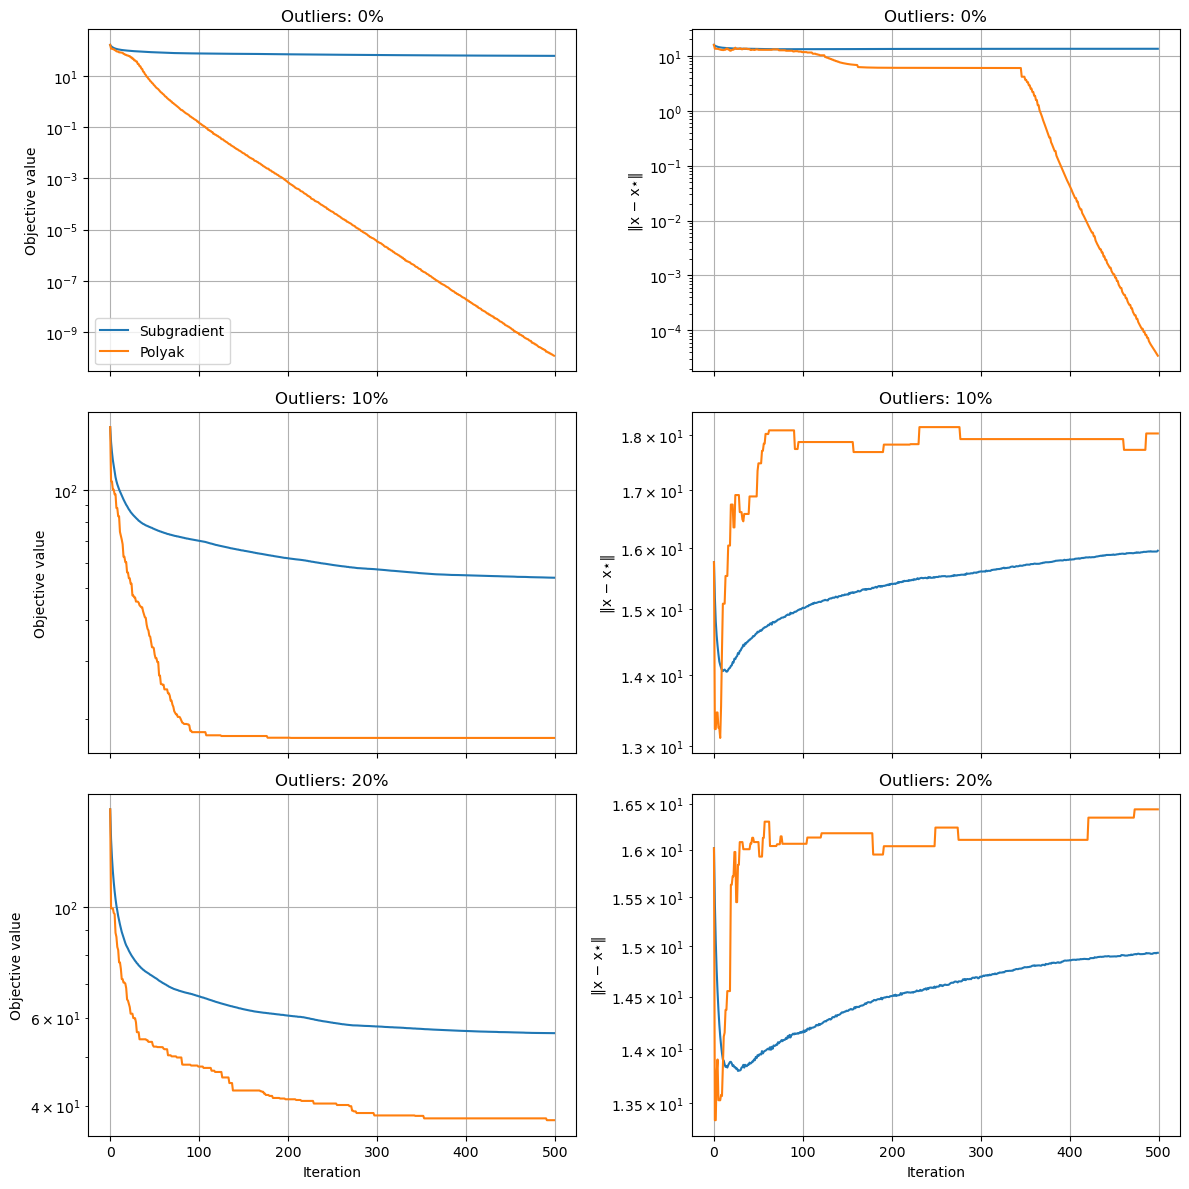

In [ ]:
rng = np.random.default_rng()
dim = 128
observ_nmbr = 3 * dim

max_iters = 500
tol = 1e-6
nmbr_of_runs = 20
outliers_magnitude = 100.0
outliers_fractions = [0.0, 0.1, 0.2]
x0 = np.ones(dim)

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 12), sharex=True
)

for i, outliers_fraction in enumerate(outliers_fractions):

    all_loss_descent = []
    all_loss_polyak = []
    all_errors_descent = []
    all_errors_polyak = []

    for seed in range(nmbr_of_runs):
        rng = np.random.default_rng(seed)
        A, b, x_true = phase_retrieval_params(
            observ_nmbr, dim, rng,
            outliers_fraction=outliers_fraction,
            outliers_magnitude=outliers_magnitude
        )

        f_target = phase_retrieval(A, b)

        # --- Subgradient descent ---
        _, history_descent = subgrad_method(
            f=f_target,
            subgrad_f=phase_retrieval_subgradient(A, b),
            step=Subgrad_descent_step(
                d=0.5,
                alpha_function=lambda k, h: 1.0 / (np.linalg.norm(h) * (k+1)**0.5)
            ),
            x0=x0,
            max_iters=max_iters,
            tol=tol
        )

        all_loss_descent.append([f_best for f_best, x in history_descent])
        all_errors_descent.append([np.linalg.norm(x - x_true) for f_best, x in history_descent])

        # --- Polyak ---
        _, history_polyak = subgrad_method(
            f=f_target,
            subgrad_f=phase_retrieval_subgradient(A, b),
            step=PolyakStepSize(f_sol=0.0, const_div=1.0),
            x0=x0,
            max_iters=max_iters,
            tol=tol
        )

        all_loss_polyak.append([f_best for f_best, x in history_polyak])
        all_errors_polyak.append([np.linalg.norm(x - x_true) for f_best, x in history_polyak])

    # Convert to arrays
    all_loss_descent = np.array(all_loss_descent)
    all_loss_polyak = np.array(all_loss_polyak)
    all_errors_descent = np.array(all_errors_descent)
    all_errors_polyak = np.array(all_errors_polyak)

    # Medians
    median_loss_descent = np.median(all_loss_descent, axis=0)
    median_loss_polyak = np.median(all_loss_polyak, axis=0)
    median_err_descent = np.median(all_errors_descent, axis=0)
    median_err_polyak = np.median(all_errors_polyak, axis=0)

    # -------- Left column: objective --------
    ax_obj = axes[i, 0]
    ax_obj.plot(median_loss_descent, label="Subgradient")
    ax_obj.plot(median_loss_polyak, label="Polyak")
    ax_obj.set_yscale("log")
    ax_obj.set_ylabel("Objective value")
    ax_obj.set_title(f"Outliers: {outliers_fraction:.0%}")
    ax_obj.grid(True)

    if i == 0:
        ax_obj.legend()

    # -------- Right column: error --------
    ax_err = axes[i, 1]
    ax_err.plot(median_err_descent, label="Subgradient")
    ax_err.plot(median_err_polyak, label="Polyak")
    ax_err.set_yscale("log")
    ax_err.set_ylabel("‖x − x⋆‖")
    ax_err.set_title(f"Outliers: {outliers_fraction:.0%}")
    ax_err.grid(True)

for ax in axes[-1, :]:
    ax.set_xlabel("Iteration")

plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()

Какие можно сделать выводы? Задача невыпуклая, поэтому теоретических гарантий для убывающего шага мы не имеем. Однако, метод сходится, хоть и с небольшой скоростью сходимости. Чем больше количество выбросов, тем менее явным становится превосходство шага Поляка. Это связано с тем, что с добавлением выбросов решение смещается, а на графиках мы мерим значение до решения `x_true`.

## SVM

hinge-loss function + $l_2$ регуляризатор:
$$\min _x f(x):=\frac{1}{n} \sum_{i=1}^n \max \left\{0,1-y_i x^T w_i\right\}+\frac{\lambda}{2}\|x\|_2^2$$
, где $\max(0,1-y(w^Tx))$ hinge-loss функция, $y_i$ - параметр выборки $\{ -1, +1\}$, который задаёт класс точек $\omega_i$.

Отметим, что задача является сильно выпуклой с параметром $\lambda$.

Шаги для сравнения

1. Убывающий шаг: $t_k = \dfrac{1}{\|f'(\mathbf{x}^k)\|\sqrt{k+1}}$
2. Убывающий шаг с константой сильной выпуклости: $t_k = \frac{2}{\lambda (k+1)}$
2. Шаг Поляка: $t_k = \frac{f(x_k)-f^*}{||f'(x^k)||^2}$

In [17]:
def svm_objective(x, W, y, lam):
    margins = 1 - y * (W @ x)
    hinge = np.maximum(0.0, margins)
    loss = hinge.mean()
    reg = (lam / 2.0) * np.dot(x, x)

    return loss + reg


def svm_subgradient(x, W, y, lam):
    margins = 1 - y * (W @ x)
    active = margins > 0

    g_hinge = (-y[active, None] * W[active]).mean(axis=0) if np.any(active) else np.zeros_like(x)

    g = g_hinge + lam * x

    return g

In [18]:
def svm_params(n, d, rng, noise=0.1):
    W_pos = rng.normal(loc=+1.0, scale=1.0, size=(n // 2, d))
    W_neg = rng.normal(loc=-1.0, scale=1.0, size=(n // 2, d))
    W = np.vstack([W_pos, W_neg])

    y = np.hstack([np.ones(n // 2), -np.ones(n // 2)])

    flip = rng.random(n) < noise
    y[flip] *= -1

    return W, y

In [19]:
rng = np.random.default_rng()
dim = 64
observ_nmbr = 3 * dim

max_iters = 500
tol = 1e-6
nmbr_of_runs = 15
reg_params = [0.01, 0.1, 2.0]
x0 = np.ones(dim)

<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\l'
C:\Users\alexa\AppData\Local\Temp\ipykernel_3192\2083380849.py:72: SyntaxWarning: invalid escape sequence '\l'
  ax_obj.plot(median_loss_strong_descent - min_all_value, label="Subgradient (1/\lamda k)")


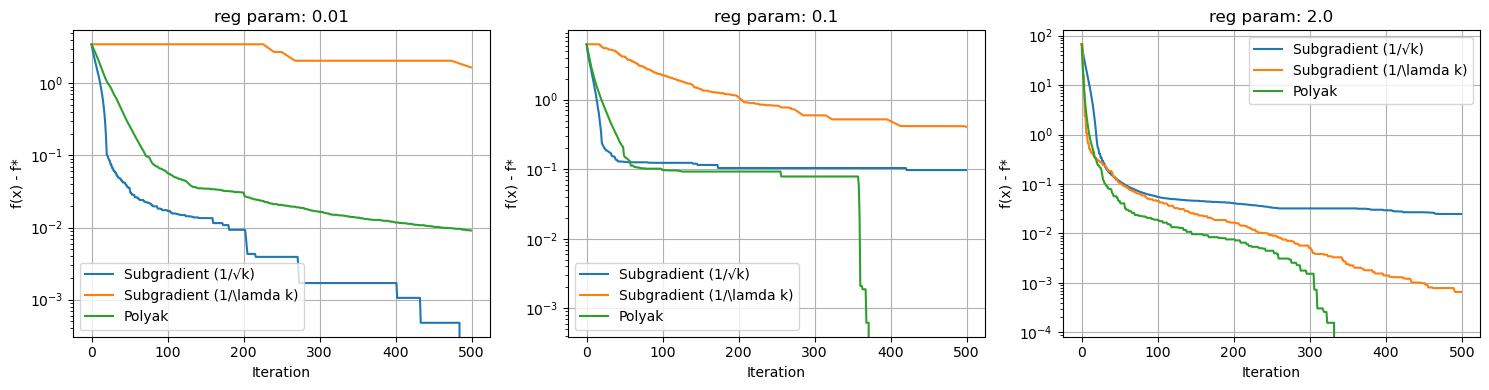

: 

In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 4), sharex=True
)

for i, reg_param in enumerate(reg_params):
    all_loss_descent = []
    all_loss_strong_descent = []
    all_loss_polyak = []

    min_f_value_for_polyak = np.inf

    for seed in range(nmbr_of_runs):
        rng = np.random.default_rng(seed)

        W, y = svm_params(n=observ_nmbr, d=dim, rng=rng, noise=0.05)

        svm_f = lambda x: svm_objective(x, W, y, lam=reg_param)
        svm_subg = lambda x: svm_subgradient(x, W, y, lam=reg_param)

        _, history = subgrad_method(
            f=svm_f,
            subgrad_f=svm_subg,
            step=Subgrad_descent_step(
                alpha_function=lambda k, h: 1.0 / (np.linalg.norm(h) * (k+1)**0.5)
            ),
            x0=x0,
            max_iters=max_iters,
            tol=tol
        )
        all_loss_descent.append([f_best for f_best, x in history])
        min_f_value_for_polyak = all_loss_descent[-1][-1] if all_loss_descent[-1][-1] < min_f_value_for_polyak else min_f_value_for_polyak

        _, history = subgrad_method(
            f=svm_f,
            subgrad_f=svm_subg,
            step=Subgrad_descent_step(
                alpha_function=lambda k, h: 2.0 / (reg_param * (k+1))
            ),
            x0=x0,
            max_iters=max_iters,
            tol=tol
        )
        all_loss_strong_descent.append([f_best for f_best, x in history])
        min_f_value_for_polyak = all_loss_strong_descent[-1][-1] if all_loss_strong_descent[-1][-1] < min_f_value_for_polyak else min_f_value_for_polyak

        _, history = subgrad_method(
            f=svm_f,
            subgrad_f=svm_subg,
            step=PolyakStepSize(f_sol=min_f_value_for_polyak, const_div=1.0),
            x0=x0,
            max_iters=max_iters,
            tol=tol
        )
        all_loss_polyak.append([f_best for f_best, x in history])

    all_loss_descent = np.array(all_loss_descent)
    all_loss_strong_descent = np.array(all_loss_strong_descent)
    all_loss_polyak = np.array(all_loss_polyak)

    median_loss_descent = np.median(all_loss_descent, axis=0)
    median_loss_strong_descent = np.median(all_loss_strong_descent, axis=0)
    median_loss_polyak = np.median(all_loss_polyak, axis=0)

    min_all_value = min(
        median_loss_descent.min(),
        median_loss_strong_descent.min(),
        median_loss_polyak.min()
    )

    ax_obj = axes[i]
    ax_obj.plot(median_loss_descent - min_all_value, label="Subgradient (1/√k)")
    ax_obj.plot(median_loss_strong_descent - min_all_value, label="Subgradient (1/\lamda k)")
    ax_obj.plot(median_loss_polyak - min_all_value, label="Polyak")
    ax_obj.set_yscale("log")
    ax_obj.set_ylabel("f(x) - f*")
    ax_obj.set_xlabel("Iteration")
    ax_obj.set_title(f"reg param: {reg_param}")
    ax_obj.grid(True)
    ax_obj.legend()

plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()

В итоге видим, что шаг с константой сильной выпуклости начинает давать явные преимущества только при достаточно высокой константе сильной выпуклости, что полностью согласуется с теорией. Шаг Поляка был лучше в 2 случаях из 3, на этот раз минимум для него мы взяли из минимального значения всех предыдущих алгоритмов.